# 01. Hello LangGraph：最小可运行的 StateGraph

> 这一节只做一件事：把“真实 LLM 调用”放进一个 node，让你看到 **MessagesState 在图里怎么流转**。

## 本节学什么

- **图怎么跑**：`StateGraph`、`START/END`、`compile()`、`invoke()`
- **状态怎么存**：`MessagesState`（核心是 `state["messages"]`）
- **节点怎么写**：node 读 `messages` → 调用模型 → `return {"messages": [response]}`

## 本节完成标准

- 你能跑通一次 `graph.invoke(...)`
- 你能解释：为什么 `messages` 会从 1 条变成 2 条（因为追加了模型回复）
- 你能区分：`compile()`（生成可执行图） vs `invoke()`（执行并返回最终 state）


## 0) 环境变量（模型配置）

- 从 `../.env` 读取 `OPENAI_API_KEY` / `OPENAI_BASE_URL`（可选）/ `OPENAI_MODEL`（可选）

In [1]:
from __future__ import annotations

import os

from dotenv import load_dotenv

load_dotenv("../.env")

# 只输出“是否配置好”，避免泄露敏感信息
print("OPENAI_API_KEY set:", bool(os.getenv("OPENAI_API_KEY")))
print("OPENAI_BASE_URL set:", bool(os.getenv("OPENAI_BASE_URL")))
print("OPENAI_MODEL:", os.getenv("OPENAI_MODEL") or "(default: gpt-4.1-mini)")

OPENAI_API_KEY set: True
OPENAI_BASE_URL set: True
OPENAI_MODEL: (default: gpt-4.1-mini)


## 1) 定义最小图：`START -> call_model -> END`

- `call_model(state)`：读 `state["messages"]` → 调用 `model.invoke(...)` → `return {"messages": [response]}`
- `StateGraph(MessagesState)`：声明 state 结构
- `add_node/add_edge`：连好边
- `compile()`：得到可执行 `graph`

一句话记住：`MessagesState` 会把你返回的 `messages` **追加**进对话历史。

### 补充说明：把它想成“对话单”在流转

- **State（`MessagesState`）**：就是一张共享的“对话单”，核心字段是 `messages: list[BaseMessage]`。
- **Node（`call_model`）**：一个处理步骤。
  - 输入：当前“对话单”（里面已经有用户的 `HumanMessage`）
  - 产出：一个很小的 update：`{"messages": [AIMessage]}`
- **关键：为什么不是直接返回完整 messages？**
  - 因为 LangGraph 的约定是：node **返回增量 update**。
  - `MessagesState` 对 `messages` 这个键自带“追加合并”的 reducer：把你返回的那 1 条新消息 append 进历史。

### 补充说明：`compile()` 和 `invoke()` 的区别

- **`builder.add_node/add_edge`**：只是把“图的结构草稿”记在 builder 里；不会执行 node。
- **`builder.compile()`**：做结构校验（节点是否存在、边是否指向合法节点等），并生成一个“可执行图”对象 `graph`。
- **`invoke()`**：才会真的调用 `call_model()`，并触发一次模型调用。

In [2]:
import os

from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph

MODEL_NAME = os.getenv("OPENAI_MODEL", "gpt-4.1-mini")
model = ChatOpenAI(model=MODEL_NAME, temperature=0)


def call_model(state: MessagesState):
    # 1) 读 state：拿到当前对话历史（包含用户输入）
    messages = state["messages"]

    # 2) 调用模型并得到一条 AIMessage
    response = model.invoke(messages)

    # 3) 返回增量 update：MessagesState 会把这条 AIMessage 追加进 messages
    return {"messages": [response]}


# 组装图
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", END)

graph = builder.compile()

## 2) 看图

- 打印 Mermaid 文本（下面一行）
- 如需图片渲染，再运行下一格（可选）

### 补充说明

- 这一步不影响执行结果：只是把 `compile()` 得到的图结构拿出来可视化。
- `draw_mermaid()`：根据图里的节点/边生成 Mermaid 文本。
- `draw_mermaid_png(...)`：把 Mermaid 文本交给渲染端生成图片。


In [3]:
# 打印图的 Mermaid 结构文本，帮助你直观理解当前的有向图结构
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	call_model(call_model)
	__end__([<p>__end__</p>]):::last
	__start__ --> call_model;
	call_model --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



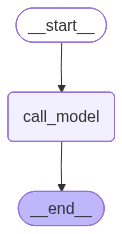

In [4]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## 3) 调用：`invoke()`

- 输入：`{"messages": [HumanMessage(...)]}`
- 输出：最终 state（`messages` 会多出 1 条模型回复）

### 解释：`invoke()` 是怎么把图跑完的

你可以把 `invoke()` 想成：把一张“对话单”从 `START` 送进流程，然后按边走到 `END`。

- **Step A：初始化 state**：你传入的 dict 会变成初始 state（此时只有 1 条 `HumanMessage`）。
- **Step B：从 `START` 找下一步**：根据你定义的边，下一步是 `call_model`。
- **Step C：执行 node（`call_model(state)`）**：
  - 读 `state["messages"]`
  - `model.invoke(messages)` 调用模型，拿到 `AIMessage`
  - 返回 update：`{"messages": [AIMessage]}`
- **Step D：合并 update 到 state**：
  - 因为是 `MessagesState`，`messages` 的合并规则是“追加”，所以最终 messages 变成 2 条。
- **Step E：走到 `END` 停止**：返回最终 state。

### 演示：把 `state` / `update` 打印出来

为了像 00 一样“看见变化”，我们用 `stream()` 看两种输出：

- `stream_mode="updates"`：看每个 node **返回的增量 update 字典**（会带 node 名）。
- `stream_mode="values"`：看每一步 **合并后的完整 state 字典快照**。

你会看到：`messages` 从 1 条（只有 HumanMessage）变成 2 条（追加了 AIMessage）。

In [5]:
# 准备一份最小的初始 state（字典）
init_state = {"messages": [HumanMessage(content="hi! 请用一句话解释什么是 LangGraph")]}

print("=== init_state（你传入图的字典）===")
print(init_state)
print("messages types:", [type(m).__name__ for m in init_state["messages"]])
print()

# 1) updates：看每个 node 返回的增量 update
print("=== stream_mode=updates：node 返回的 update（字典）===")
for chunk in graph.stream(init_state, stream_mode="updates"):
    print(chunk)
print()

# 2) values：看每一步合并后的完整 state 快照
print("=== stream_mode=values：每一步合并后的 state（字典快照）===")
for i, state_snapshot in enumerate(graph.stream(init_state, stream_mode="values")):
    msgs = state_snapshot["messages"]
    last = msgs[-1]
    content = getattr(last, "content", "")
    if isinstance(content, str) and len(content) > 120:
        content = content[:120] + "..."
    print(f"-- step {i} --")
    print("messages length:", len(msgs))
    print("last message type:", type(last).__name__)
    print("last message content:", content)
    print("state keys:", list(state_snapshot.keys()))
    print()

=== init_state（你传入图的字典）===
{'messages': [HumanMessage(content='hi! 请用一句话解释什么是 LangGraph', additional_kwargs={}, response_metadata={})]}
messages types: ['HumanMessage']

=== stream_mode=updates：node 返回的 update（字典）===
{'call_model': {'messages': [AIMessage(content='LangGraph 是一个用于构建和管理多模态语言模型推理流程的图形化工具，帮助用户直观地设计和执行复杂的语言任务。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 18, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'service_ttft_ms': 721, 'user_visible_ttft_ms': 614, 'total_duration_ms': 2534, 'pre_inference_ms': 107, 'service_tbt_ms': 52, 'service_ttlt_ms': 2629, 'engine_ttft_ms': 203, 'engine_ttlt_ms': 2115, 'engine_tbt_ms': 52}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerpri

In [6]:
# 调用图：返回最终 state（字典）
result = graph.invoke(init_state)
messages = result["messages"]
print("messages length:", len(messages))
print("last message type:", type(messages[-1]).__name__)
print("last message content:\n", messages[-1].content)

messages length: 2
last message type: AIMessage
last message content:
 LangGraph 是一个用于构建和管理多模态语言模型推理流程的图形化工具或框架。


## 4) 小结：你已经掌握了 LangGraph 的最小闭环

到这里你已经会：

- 用 `MessagesState` 表达对话状态
- 写一个“真实 LLM 节点”并把回复追加到 state
- 用 `START/END` 串起一张最小图
- `compile()` 得到可执行图，`invoke()` 跑一次得到最终 state

一句话总结这一节的关键点：

> **node 只返回增量 update；LangGraph 负责按边调度 node，并按 state 的 reducer 规则把 update 合并回去。**